<a href="https://colab.research.google.com/github/Neeveszr/Investigacao_Estatistica_Probabilistica_e_Visual-Brazilian-E-Commerce/blob/main/Investiga%C3%A7%C3%A3o_Estat%C3%ADstica%2C_Probabil%C3%ADstica_e_Visual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset: Brazillian E-Commerce (Olist)

*Integrantes:*

*   Antonio Neves Aguiar Neto
*   Wickham Carneiro Pereira
*   Marcelo Sampaio de Sousa
*   Thayanne Oliveira Silva
*   Yasmin Moreira de Sousa

Bases usadas: customers, order_items, orders, products

# Parte 1 — Limpeza e Estruturação

## Importações

In [ ]:
# Imports necessários em todo o projeto
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import kagglehub
import pandas as pd
import os

## Carregando Datasets, fazendo Merge e limpeza estrutural

In [ ]:
# Carregando os datasets
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

df_customers = pd.read_csv(os.path.join(path, "olist_customers_dataset.csv"))
df_orders    = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
df_items     = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
df_products  = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


In [ ]:
# Inspeção Inicial
print("Customers:", df_customers.shape)
print("Orders:", df_orders.shape)
print("Order items:", df_items.shape)
print("Products:", df_products.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order items: (112650, 7)
Products: (32951, 9)


In [ ]:
# Tratamento inicial do dataset antes do Merge
# Pra evitar perder algumas informações e padronizar o tipo de algumas colunas

# Converter colunas de data para datetime
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'], errors='coerce')
df_orders['order_approved_at'] = pd.to_datetime(df_orders['order_approved_at'], errors='coerce')
df_orders['order_delivered_carrier_date'] = pd.to_datetime(df_orders['order_delivered_carrier_date'], errors='coerce')
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'], errors='coerce')
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'], errors='coerce')
df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'], errors='coerce')

# Converter CEP para string, também será mantido como categórico, pois funciona como identificador geográfico e não como medida quantitativa
df_customers['customer_zip_code_prefix'] = df_customers['customer_zip_code_prefix'].astype(str).str.zfill(5)

# Ajustar colunas de products que representam contagem/tamanho
df_products['product_name_lenght'] = df_products['product_name_lenght'].astype('Int64')
df_products['product_description_lenght'] = df_products['product_description_lenght'].astype('Int64')
df_products['product_photos_qty'] = df_products['product_photos_qty'].astype('Int64')

# Tratar valores ausentes básicos em products
df_products['product_category_name'] = df_products['product_category_name'].fillna('desconhecida')

In [ ]:
# Merge para unir os datasets.
# Optamos por uma análise orientada aos pedidos.

df_items_pedido = (
    df_items.groupby('order_id')
    .agg(
        qtd_itens=('order_item_id', 'count'),
        valor_produtos=('price', 'sum'),
        valor_frete=('freight_value', 'sum'),
        qtd_produtos_distintos=('product_id', 'nunique')
    )
    .reset_index()
)

df_pedidos = (
    df_orders
    .merge(df_items_pedido, on='order_id', how='left')
    .merge(df_customers, on='customer_id', how='left')
)

# Mais um merge, dessa vez para aparecer as informações dos produtos em cada pedido no dataframe.
# Assim possibilitamos a construção de Features relacionadas a caracteristicas dos produtos.

df_items_prod = df_items.merge(df_products, on='product_id', how='left')

df_prod_pedido = (
    df_items_prod.groupby('order_id')
    .agg(
        peso_total_g=('product_weight_g', 'sum'),
        comprimento_medio_cm=('product_length_cm', 'mean'),
        altura_media_cm=('product_height_cm', 'mean'),
        largura_media_cm=('product_width_cm', 'mean'),
        qtd_categorias_distintas=('product_category_name', 'nunique')
    )
    .reset_index()
)

df_pedidos = df_pedidos.merge(df_prod_pedido, on='order_id', how='left')
print("Base final integrada:", df_pedidos.shape)
df_pedidos.head()

Base final integrada: (99441, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,qtd_itens,valor_produtos,...,qtd_produtos_distintos,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,peso_total_g,comprimento_medio_cm,altura_media_cm,largura_media_cm,qtd_categorias_distintas
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,29.99,...,1.0,7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,500.0,19.0,8.0,13.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,118.70,...,1.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,400.0,19.0,13.0,19.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,159.90,...,1.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,420.0,24.0,19.0,21.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,45.00,...,1.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,450.0,30.0,10.0,20.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,19.90,...,1.0,72632f0f9dd73dfee390c9b22eb56dd6,09195,santo andre,SP,250.0,51.0,15.0,15.0,1.0


## Exploração Inicial


In [ ]:
# Mostrando as respectivas colunas no dataset após o Merge
print("Colunas do dataset: ")
print("\n")
print(df_pedidos.columns)

print("\n")

print("Quantidade de colunas:", len(df_pedidos.columns))
print(df_pedidos.columns.tolist())

print("\n")

# Mostrando o tipo de dado de cada coluna
print("Tipos de dados: ")
print("\n")
print(df_pedidos.dtypes)

Colunas do dataset: 


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'qtd_itens', 'valor_produtos', 'valor_frete', 'qtd_produtos_distintos',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'peso_total_g', 'comprimento_medio_cm',
       'altura_media_cm', 'largura_media_cm', 'qtd_categorias_distintas'],
      dtype='object')


Quantidade de colunas: 21
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'qtd_itens', 'valor_produtos', 'valor_frete', 'qtd_produtos_distintos', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'peso_total_g', 'comprimento_medio_cm', 'altura_media_cm', 'largura_media_c

Classificação das variáveis por escala de mensuração

| Coluna | Classificação |
|---|---|
| `order_id` | Nominal |
| `customer_id` | Nominal |
| `order_status` | Nominal |
| `order_purchase_timestamp` | Intervalar |
| `order_approved_at` | Intervalar |
| `order_delivered_carrier_date` | Intervalar |
| `order_delivered_customer_date` | Intervalar |
| `order_estimated_delivery_date` | Intervalar |
| `qtd_itens` | Razão |
| `valor_produtos` | Razão |
| `valor_frete` | Razão |
| `qtd_produtos_distintos` | Razão |
| `customer_unique_id` | Nominal |
| `customer_zip_code_prefix` | Nominal |
| `customer_city` | Nominal |
| `customer_state` | Nominal |
| `peso_total_g` | Razão |
| `comprimento_medio_cm` | Razão |
| `altura_media_cm` | Razão |
| `largura_media_cm` | Razão |
| `qtd_categorias_distintas` | Razão |

In [ ]:
# Mostrando as 5 primeiras linhas do dataset já unificado
# Buscamos conferir principalmente se o Merge deu certo
print("Visualização inicial da base integrada:")
display(df_pedidos.head())

Visualização inicial da base integrada:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,qtd_itens,valor_produtos,...,qtd_produtos_distintos,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,peso_total_g,comprimento_medio_cm,altura_media_cm,largura_media_cm,qtd_categorias_distintas
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,29.99,...,1.0,7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,500.0,19.0,8.0,13.0,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,118.70,...,1.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,400.0,19.0,13.0,19.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,159.90,...,1.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,420.0,24.0,19.0,21.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,45.00,...,1.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,450.0,30.0,10.0,20.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,19.90,...,1.0,72632f0f9dd73dfee390c9b22eb56dd6,09195,santo andre,SP,250.0,51.0,15.0,15.0,1.0


In [ ]:
# Mostrar as informações gerais sobre o dataframe:
print("Informações gerais sobre o dataframe: ")
print("\n")
df_pedidos.info()

Informações gerais sobre o dataframe: 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   qtd_itens                      98666 non-null  float64       
 9   valor_produtos                 98666 non-null  float64       
 10  valor_frete                    98666 non-

In [ ]:
# Mostrar informações descritivas sobre o dataframe:
print("Informações descritivas sobre o dataframe: ")
print("\n")
df_pedidos.describe()

Informações descritivas sobre o dataframe: 




,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,qtd_itens,valor_produtos,valor_frete,qtd_produtos_distintos,peso_total_g,comprimento_medio_cm,altura_media_cm,largura_media_cm,qtd_categorias_distintas
count,99441,99281,97658,96476,99441,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000,98650.000000,98650.000000,98650.000000,98666.000000
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,1.141731,137.754076,22.823562,1.038098,2390.027669,30.099939,16.485058,23.022745,1.008149
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1.000000,0.850000,0.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,1.000000,45.900000,13.850000,1.000000,300.000000,18.000000,8.000000,15.000000,1.000000
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,1.000000,86.900000,17.170000,1.000000,750.000000,25.000000,13.000000,20.000000,1.000000
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,1.000000,149.900000,24.040000,1.000000,2066.750000,38.000000,20.000000,30.000000,1.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,21.000000,13440.000000,1794.960000,8.000000,184400.000000,105.000000,105.000000,118.000000,3.000000
std,NaN,NaN,NaN,NaN,NaN,0.538452,210.645145,21.650909,0.226456,4773.239825,16.079329,13.282452,11.706495,0.091909


## Tratamento pós-merge

### Nulos

In [ ]:
df_pedidos.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0
qtd_itens,775
valor_produtos,775


Em relação aos nulos, percebemos que alguns significam algo, como order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date. Mas outros como os relacionados a medidas dos itens, quantidade e valores ocorreram por falta de informação.

Após análise decidimos corrigir os relacionados a medidas por mediana e removemos as linhas com nulos em qtd_itens, pois percebemos que essas linhas são as mesmas que acabam retornando nulos em valor_Frete, qtd_produtos_distintos e valor_produtos, e como elas representam menos de 1% da base de dados, removemos para evitar problemas no futuro.

In [ ]:
# Atribuir mediana nas colunas de comprimento, altura e largura
cols_mediana = [
    'comprimento_medio_cm',
    'altura_media_cm',
    'largura_media_cm'
]

for col in cols_mediana:
    print(f"{col} - antes:", df_pedidos[col].isnull().sum())
    df_pedidos[col] = df_pedidos[col].fillna(df_pedidos[col].median())
    print(f"{col} - depois:", df_pedidos[col].isnull().sum())


comprimento_medio_cm - antes: 791
comprimento_medio_cm - depois: 0
altura_media_cm - antes: 791
altura_media_cm - depois: 0
largura_media_cm - antes: 791
largura_media_cm - depois: 0


In [ ]:
# Removendo as linhas com NaN em qtd_itens
antes = len(df_pedidos)
nulos_qtd_itens = df_pedidos['qtd_itens'].isnull().sum()

df_pedidos = df_pedidos.dropna(subset=['qtd_itens'])

depois = len(df_pedidos)

print("Nulos em qtd_itens removidos:", nulos_qtd_itens)
print("Linhas antes:", antes)
print("Linhas depois:", depois)
print("Percentual removido: {:.2f}%".format((antes - depois) / antes * 100))


Nulos em qtd_itens removidos: 775
Linhas antes: 99441
Linhas depois: 98666
Percentual removido: 0.78%


In [ ]:
nulos_restantes = df_pedidos.isnull().sum().sort_values(ascending=False)
display(nulos_restantes[nulos_restantes > 0])

,0
order_delivered_customer_date,2190
order_delivered_carrier_date,1009
order_approved_at,14


### Duplicatas

In [ ]:
# Checar quantidade de duplicatas
duplicated_rows = df_pedidos[df_pedidos.duplicated()]
print("Quantidade de linhas duplicadas:", duplicated_rows.shape[0])

if duplicated_rows.shape[0] > 0:
    display(duplicated_rows.head())

Quantidade de linhas duplicadas: 0


Não foi identificado linhas totalmente duplicatas na análise

### Inconsistências

In [ ]:
# Correção de inconsistências objetivas
df_pedidos = df_pedidos.copy()

qtd_peso_invalido = (df_pedidos['peso_total_g'] <= 0).sum()

print(f"Registros com peso_total_g menor ou igual a zero a serem removidos: {qtd_peso_invalido}")

# Remoção apenas dos casos claramente inconsistentes
df_pedidos = df_pedidos[df_pedidos['peso_total_g'] > 0].copy()

print(f"Quantidade de linhas após a correção: {len(df_pedidos)}")

Registros com peso_total_g menor ou igual a zero a serem removidos: 22
Quantidade de linhas após a correção: 98644


## Outliers




Outliers detectados por coluna (método IQR):


,Quantidade de outliers,Percentual (%)
valor_produtos,7912,8.02
valor_frete,9939,10.08
peso_total_g,13804,13.99



Resumo geral da remoção:
Total de registros antes: 98,644
Total de registros depois: 76,893
Registros removidos: 21,751 (22.05%)


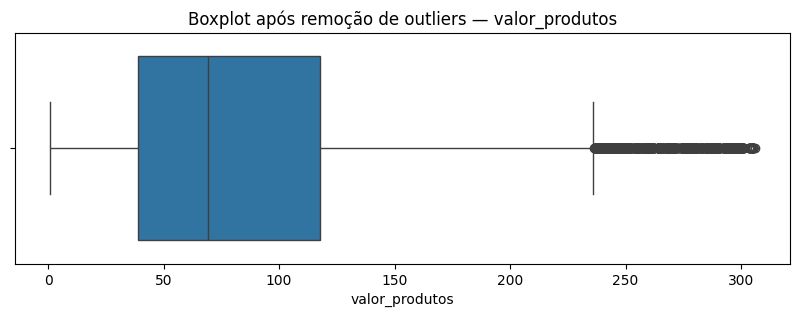

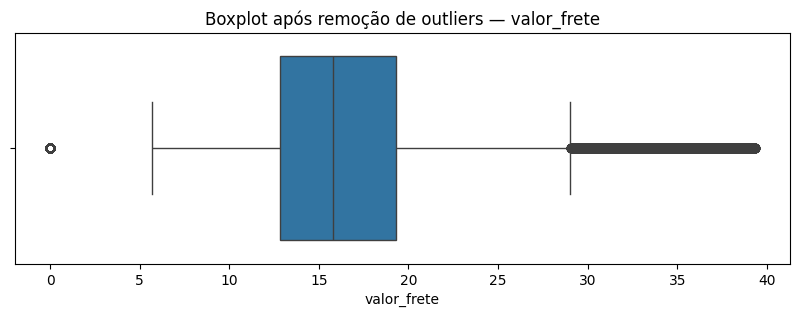

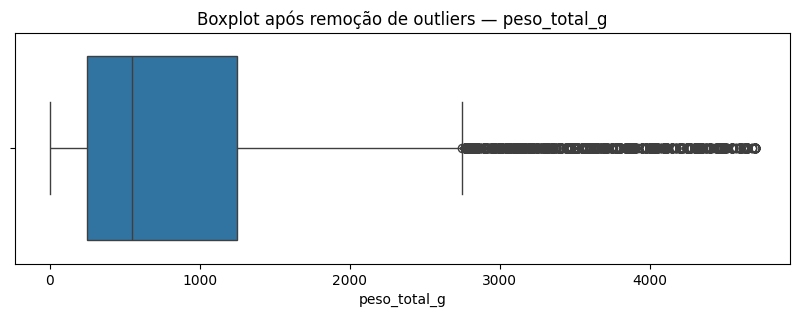

In [ ]:
# Variáveis principais escolhidas para o tratamento global de outliers
colunas_outliers = ['valor_produtos', 'valor_frete', 'peso_total_g']

# Cálculo dos quartis e do IQR
Q1 = df_pedidos[colunas_outliers].quantile(0.25)
Q3 = df_pedidos[colunas_outliers].quantile(0.75)
IQR = Q3 - Q1

# Definição dos limites inferior e superior
limite_inferior = (Q1 - 1.5 * IQR).clip(lower=0)
limite_superior = Q3 + 1.5 * IQR

# Identificação dos outliers por coluna
outliers_iqr = (
    (df_pedidos[colunas_outliers] < limite_inferior) |
    (df_pedidos[colunas_outliers] > limite_superior)
)

# Resumo da detecção
resumo_outliers = pd.DataFrame({
    'Quantidade de outliers': outliers_iqr.sum(),
    'Percentual (%)': (outliers_iqr.sum() / len(df_pedidos) * 100).round(2)
})

print("Outliers detectados por coluna (método IQR):")
display(resumo_outliers)

# Remoção de linhas com pelo menos um outlier nas variáveis principais
mask = ~outliers_iqr.any(axis=1)
df_sem_outliers = df_pedidos.loc[mask].copy()

# Resumo da remoção
qtd_removidas = len(df_pedidos) - len(df_sem_outliers)
percentual_removido = qtd_removidas / len(df_pedidos) * 100

print("\nResumo geral da remoção:")
print(f"Total de registros antes: {len(df_pedidos):,}")
print(f"Total de registros depois: {len(df_sem_outliers):,}")
print(f"Registros removidos: {qtd_removidas:,} ({percentual_removido:.2f}%)")

# Boxplots após a remoção
for col in colunas_outliers:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df_sem_outliers[col])
    plt.title(f'Boxplot após remoção de outliers — {col}')
    plt.xlabel(col)
    plt.show()

## Exportação do Dataset Tratado

In [ ]:
import os

# Caminho da pasta no Google Drive
pasta_saida = '/content/drive/MyDrive/Trabalho Nota 2'
os.makedirs(pasta_saida, exist_ok=True)

# Caminho completo do arquivo
caminho_saida = os.path.join(pasta_saida, 'df_sem_outliers.csv')

# Exportação
df_sem_outliers.to_csv(caminho_saida, index=False, encoding='utf-8-sig')

print(f"Dataset limpo exportado com sucesso para: {caminho_saida}")

Dataset limpo exportado com sucesso para: /content/drive/MyDrive/Trabalho Nota 2/df_sem_outliers.csv


# Parte 2 — Análise Estatística, Probabilística e Visual

Nesta etapa, as análises foram realizadas com a base `df_sem_outliers`, gerada na Parte 1 após o tratamento dos valores extremos pelo método do IQR nas variáveis principais da análise.

## Análise Univariada (Medidas de Tendência Central, Dispersão e Forma)


ANÁLISE UNIVARIADA: valor_produtos
Média: 85.30
Mediana: 69.20
Moda: 59.90
Variância: 3776.50
Desvio padrão: 61.45
Amplitude: 305.05
Assimetria (Skewness): 1.22
Curtose (Kurtosis): 1.18


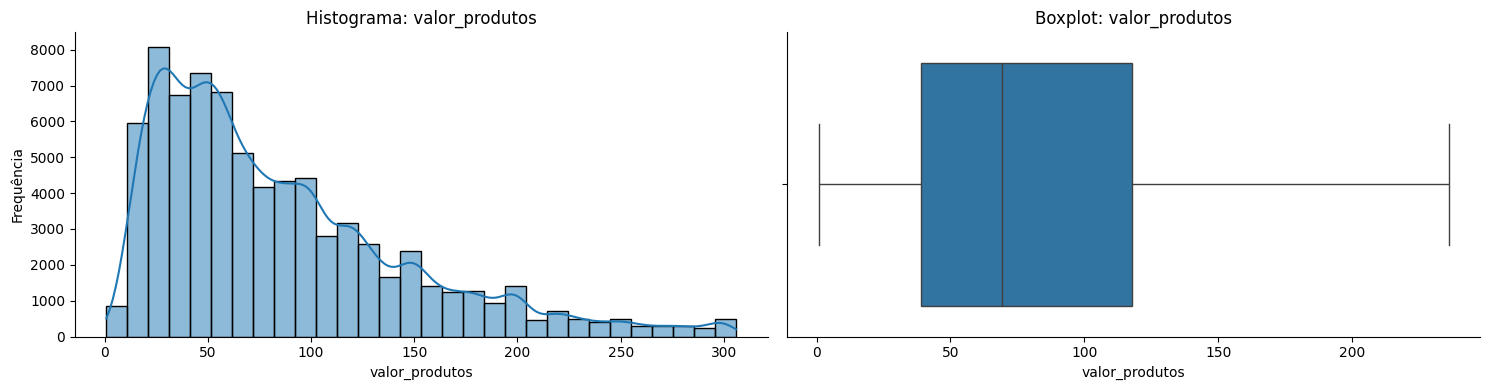


ANÁLISE UNIVARIADA: valor_frete
Média: 16.97
Mediana: 15.79
Moda: 15.10
Variância: 45.25
Desvio padrão: 6.73
Amplitude: 39.32
Assimetria (Skewness): 1.03
Curtose (Kurtosis): 1.31


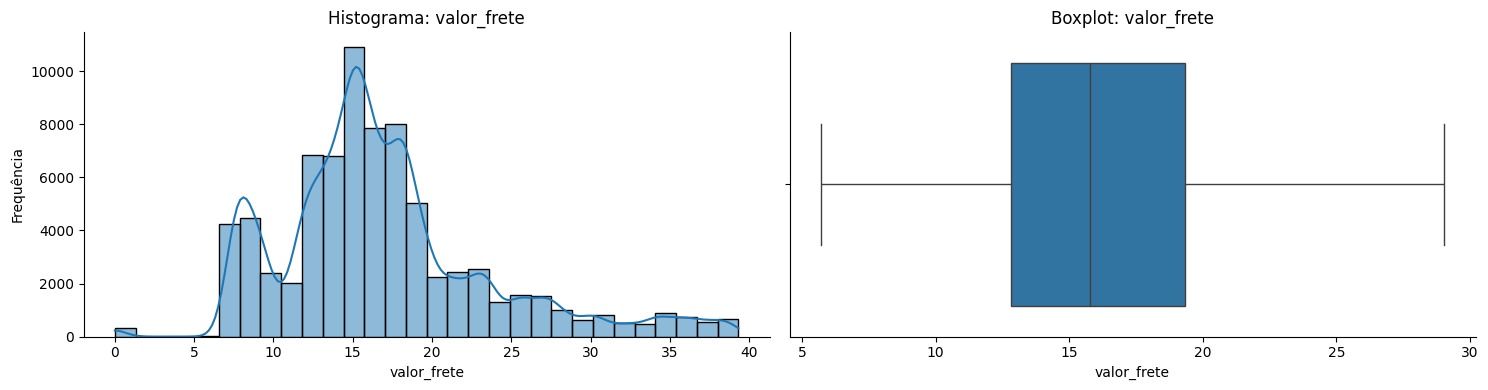


ANÁLISE UNIVARIADA: peso_total_g
Média: 906.59
Mediana: 550.00
Moda: 200.00
Variância: 854500.78
Desvio padrão: 924.39
Amplitude: 4698.00
Assimetria (Skewness): 1.75
Curtose (Kurtosis): 2.88


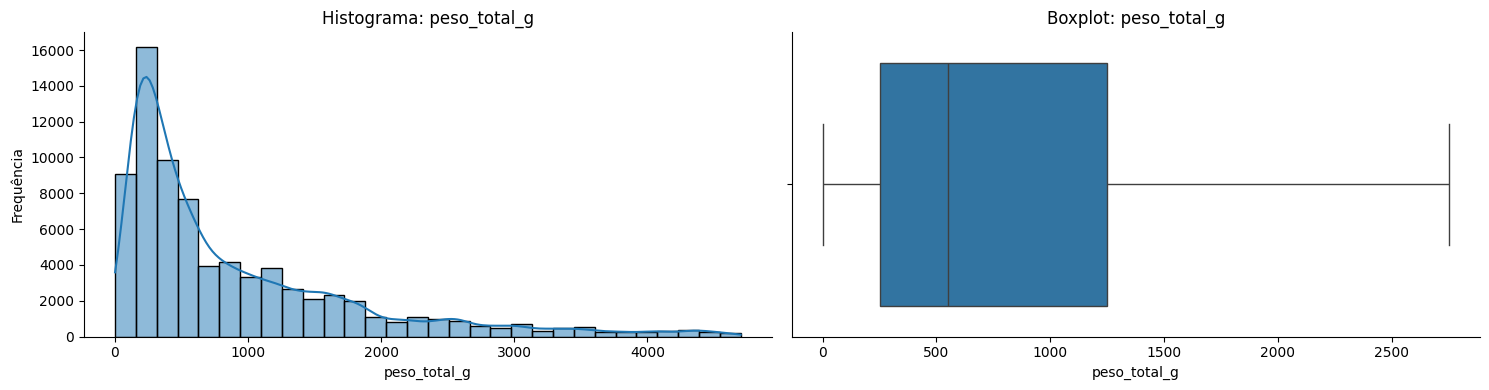

In [ ]:
from scipy.stats import skew, kurtosis

colunas_analise = ['valor_produtos', 'valor_frete', 'peso_total_g']

for coluna in colunas_analise:
    dados = df_sem_outliers[coluna]

    media = dados.mean()
    mediana = dados.median()
    moda = dados.mode()[0]
    variancia = dados.var()
    desvio_padrao = dados.std()
    amplitude = dados.max() - dados.min()
    assimetria = skew(dados)
    curtose_valor = kurtosis(dados)

    print(f"\n{'='*60}")
    print(f"ANÁLISE UNIVARIADA: {coluna}")
    print(f"{'='*60}")
    print(f"Média: {media:.2f}")
    print(f"Mediana: {mediana:.2f}")
    print(f"Moda: {moda:.2f}")
    print(f"Variância: {variancia:.2f}")
    print(f"Desvio padrão: {desvio_padrao:.2f}")
    print(f"Amplitude: {amplitude:.2f}")
    print(f"Assimetria (Skewness): {assimetria:.2f}")
    print(f"Curtose (Kurtosis): {curtose_valor:.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    sns.histplot(dados, bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma: {coluna}')
    axes[0].set_xlabel(coluna)
    axes[0].set_ylabel('Frequência')

    sns.boxplot(x=dados, ax=axes[1], showfliers=False)
    axes[1].set_title(f'Boxplot: {coluna}')
    axes[1].set_xlabel(coluna)

    sns.despine()
    plt.tight_layout()
    plt.show()

## Probabilidade

In [ ]:
# Probabilidade

print(f"\n{'='*60}")
print("ANÁLISE DE PROBABILIDADE")
print(f"{'='*60}")

total_pedidos = len(df_sem_outliers)
pedidos_caros = (df_sem_outliers['valor_produtos'] > 100).sum()
prob_caro = pedidos_caros / total_pedidos

print("\nProbabilidade de um pedido custar mais que R$ 100")
print(f"{'-'*60}")
print(f"Pedidos acima de R$ 100: {pedidos_caros}")
print(f"Total de pedidos:        {total_pedidos}")
print(f"Probabilidade:           {prob_caro:.2%}")

filtro_caro = df_sem_outliers[df_sem_outliers['valor_produtos'] > 100]
frete_alto_dado_caro = (filtro_caro['valor_frete'] > 20).sum()
prob_condicional = frete_alto_dado_caro / len(filtro_caro)

print("\nProbabilidade condicional de o frete ser maior que R$ 20")
print("dado que o pedido custa mais que R$ 100")
print(f"{'-'*60}")
print(f"Pedidos com frete > R$ 20 entre os pedidos caros: {frete_alto_dado_caro}")
print(f"Total de pedidos caros:                           {len(filtro_caro)}")
print(f"Probabilidade condicional:                        {prob_condicional:.2%}")


ANÁLISE DE PROBABILIDADE

Probabilidade de um pedido custar mais que R$ 100
------------------------------------------------------------
Pedidos acima de R$ 100: 23200
Total de pedidos:        76893
Probabilidade:           30.17%

Probabilidade condicional de o frete ser maior que R$ 20
dado que o pedido custa mais que R$ 100
------------------------------------------------------------
Pedidos com frete > R$ 20 entre os pedidos caros: 8101
Total de pedidos caros:                           23200
Probabilidade condicional:                        34.92%


## Análise Bivariada


ANÁLISE BIVARIADA

Correlação entre peso_total_g e valor_frete
------------------------------------------------------------
Correlação de Pearson:  0.31
Correlação de Spearman: 0.33




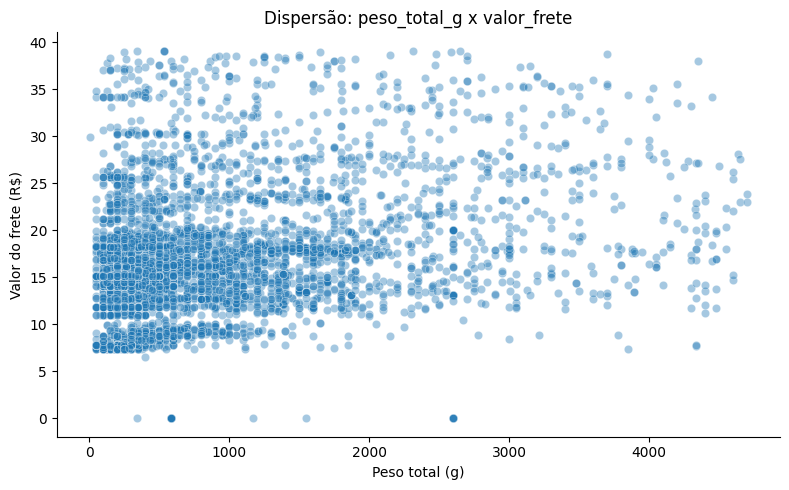


ASSOCIAÇÃO ENTRE VARIÁVEL CATEGÓRICA E NUMÉRICA


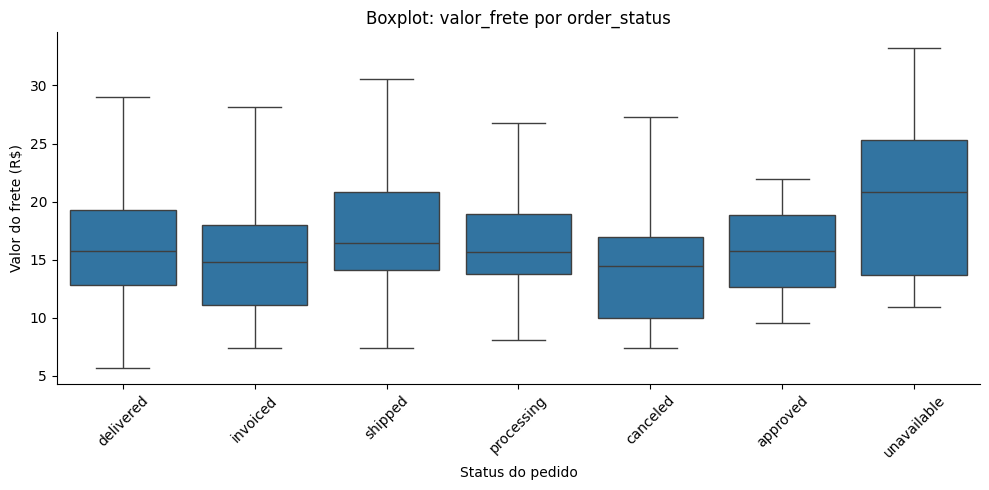

In [ ]:
from scipy.stats import pearsonr, spearmanr

print(f"\n{'='*60}")
print("ANÁLISE BIVARIADA")
print(f"{'='*60}")

pearson_corr, _ = pearsonr(df_sem_outliers['peso_total_g'], df_sem_outliers['valor_frete'])
spearman_corr, _ = spearmanr(df_sem_outliers['peso_total_g'], df_sem_outliers['valor_frete'])

print("\nCorrelação entre peso_total_g e valor_frete")
print(f"{'-'*60}")
print(f"Correlação de Pearson:  {pearson_corr:.2f}")
print(f"Correlação de Spearman: {spearman_corr:.2f}")
print("\n")

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_sem_outliers.sample(min(5000, len(df_sem_outliers)), random_state=42),
    x='peso_total_g',
    y='valor_frete',
    alpha=0.4
)
plt.title('Dispersão: peso_total_g x valor_frete')
plt.xlabel('Peso total (g)')
plt.ylabel('Valor do frete (R$)')
sns.despine()
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("ASSOCIAÇÃO ENTRE VARIÁVEL CATEGÓRICA E NUMÉRICA")
print(f"{'='*60}")

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_sem_outliers,
    x='order_status',
    y='valor_frete',
    showfliers=False
)
plt.title('Boxplot: valor_frete por order_status')
plt.xlabel('Status do pedido')
plt.ylabel('Valor do frete (R$)')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()